# Boulevard Boosters Demo

This notebook demonstrates the sklearn-compatible release API:

- `bd.DropoutBooster`
- `bd.ParallelBooster`
- `bd.ExplainableBooster`

Recommended first-use pattern:

1. Use `DropoutBooster` or `ParallelBooster` for low-dimensional smooth regression signals.
2. Use `ExplainableBooster` as the first option when dimension grows and an additive/main-effect model is acceptable.
3. Fit the model, call `prepare_inference`, then call `predict` or `predict_intervals`.

The intervals here are asymptotic research intervals. Prediction intervals are usually more stable than signal confidence intervals because they include residual noise variance.


## DropoutBooster and ParallelBooster Starting Rule

`DropoutBooster` and `ParallelBooster` are best treated as low-dimensional smooth-regression tools. Start with the table below, then increase capacity only when the fitted curve visibly underfits.

Use **effective dimension**, not just raw column count. A 20-column additive signal can still behave like a 1D/main-effect problem; a dense 5-way interaction is much harder. For genuinely high-dimensional problems, prefer `ExplainableBooster` first.

| Common case | Training rows | Shared tree shape |
| --- | ---: | --- |
| 1D or mostly additive | around 1,000 | `max_leaf_nodes=32-64`, `max_depth=6`, `min_samples_leaf=4-12`, `max_bins=64`, `subsample_rate=0.8` |
| Mostly pairwise interactions | around 5,000 | `max_leaf_nodes=96-160`, `max_depth=8`, `min_samples_leaf=4-20`, `max_bins=64-128`, `subsample_rate=0.85` |
| Clear 3-way interactions | around 20,000 | `max_leaf_nodes=192-256`, `max_depth=9`, `min_samples_leaf=4-20`, `max_bins=64-128`, `subsample_rate=0.9-1.0` |

Then choose the boosting budget:

| Estimator | Starting budget |
| --- | --- |
| `DropoutBooster` | Use `dropout_rate=0.3` for 1D/additive, `0.15` for pairwise, and `0.1` for 3-way structure. Try `max_iter=200-500`, `800-1200`, and `1500-2000` for the three rows above. |
| `ParallelBooster` | Use the same tree shape. Try `trees_per_round=4`, `4-6`, and `6-8` for the three rows above. Pick `n_rounds` so `n_rounds * trees_per_round` is similar to the `DropoutBooster` tree budget, with at least 50 rounds. Use `n_jobs=-1` only when the per-round slots are large enough to benefit from parallelism. |

Quick diagnostics: if RMSE is high and the prediction is too flat, increase `max_leaf_nodes`, `max_depth`, `max_bins`, and the tree budget. If confidence intervals are narrow but miss the signal in curved regions, that is usually approximation bias rather than noise variance. If prediction intervals cover noisy outcomes but confidence intervals miss the signal, the model is probably fitting the mean too coarsely.


In [6]:
import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import boulevard as bd


## Helper functions

In [7]:
def rmse(target, pred):
    return float(np.sqrt(mean_squared_error(target, pred)))


def coverage(target, lower, upper):
    return float(np.mean((target >= lower) & (target <= upper)))


def width_quantiles(lower, upper):
    return np.quantile(upper - lower, [0.05, 0.5, 0.95])


def split_train_calib_test(X, y, signal, *, seed=0):
    X_train, X_hold, y_train, y_hold, _signal_train, signal_hold = train_test_split(
        X,
        y,
        signal,
        test_size=0.4,
        random_state=seed,
    )
    X_calib, X_test, y_calib, y_test, _signal_calib, signal_test = train_test_split(
        X_hold,
        y_hold,
        signal_hold,
        test_size=0.5,
        random_state=seed + 1,
    )
    return X_train, X_calib, X_test, y_train, y_calib, y_test, signal_test


def timed_fit_prepare(model, X_train, y_train, X_calib, y_calib):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    model.prepare_inference(X_calib, y_calib)
    prep_seconds = time.perf_counter() - start
    return fit_seconds, prep_seconds


def evaluate_model(model, X_test, y_test, signal_test):
    start = time.perf_counter()
    pred = model.predict(X_test)
    pred_seconds = time.perf_counter() - start

    intervals = {}
    interval_seconds = {}
    for mode in ["confidence", "prediction", "reproduction"]:
        start = time.perf_counter()
        intervals[mode] = model.predict_intervals(X_test, level=0.95, mode=mode)
        interval_seconds[mode] = time.perf_counter() - start

    ci_lower, ci_upper, _ = intervals["confidence"]
    pi_lower, pi_upper, _ = intervals["prediction"]
    return {
        "pred": pred,
        "intervals": intervals,
        "pred_seconds": pred_seconds,
        "interval_seconds": interval_seconds,
        "rmse_signal": rmse(signal_test, pred),
        "rmse_y": rmse(y_test, pred),
        "ci_coverage": coverage(signal_test, ci_lower, ci_upper),
        "pi_coverage": coverage(y_test, pi_lower, pi_upper),
        "ci_width_quantiles": width_quantiles(ci_lower, ci_upper),
    }


## Low-Dimensional Example: DropoutBooster and ParallelBooster

For one-dimensional or otherwise very low-dimensional smooth signals, the histogram-tree BRAT estimators are the main examples. This section fits both estimators on the same sinusoidal regression problem and compares confidence, prediction, and reproduction intervals.


In [3]:
rng = np.random.default_rng(0)


def signal_1d(X):
    return np.sin(2 * np.pi * X[:, 0])


X_1d = rng.uniform(0.0, 1.0, size=(1000, 1))
signal_1d_values = signal_1d(X_1d)
y_1d = signal_1d_values + rng.normal(scale=0.2, size=X_1d.shape[0])

X1_train, X1_calib, X1_test, y1_train, y1_calib, y1_test, signal1_test = (
    split_train_calib_test(X_1d, y_1d, signal_1d_values)
)

low_dim_models = {
    "DropoutBooster": bd.DropoutBooster(
        max_iter=700,
        learning_rate=0.8,
        dropout_rate=0.1,
        subsample_rate=0.8,
        max_depth=6,
        max_leaf_nodes=64,
        min_samples_leaf=2,
        max_bins=64,
        random_state=0,
    ),
    "ParallelBooster": bd.ParallelBooster(
        n_rounds=70,
        trees_per_round=6,
        subsample_rate=0.8,
        max_depth=8,
        max_leaf_nodes=64,
        min_samples_leaf=4,
        max_bins=64,
        drop_first_round=True,
        n_jobs=1,
        random_state=0,
    ),
}

low_dim_results = {}
for name, model in low_dim_models.items():
    fit_seconds, prep_seconds = timed_fit_prepare(
        model,
        X1_train,
        y1_train,
        X1_calib,
        y1_calib,
    )
    metrics = evaluate_model(model, X1_test, y1_test, signal1_test)
    metrics["fit_seconds"] = fit_seconds
    metrics["prep_seconds"] = prep_seconds
    low_dim_results[name] = metrics

for name, metrics in low_dim_results.items():
    print(f"\n{name}")
    print(f"  fit seconds: {metrics['fit_seconds']:.3f}")
    print(f"  prepare_inference seconds: {metrics['prep_seconds']:.3f}")
    print(f"  predict seconds: {metrics['pred_seconds']:.4f}")
    print(f"  RMSE vs signal: {metrics['rmse_signal']:.4f}")
    print(f"  RMSE vs noisy y: {metrics['rmse_y']:.4f}")
    print(f"  signal CI coverage: {metrics['ci_coverage']:.3f}")
    print(f"  noisy-y PI coverage: {metrics['pi_coverage']:.3f}")
    print(f"  CI width q05/q50/q95: {metrics['ci_width_quantiles']}")



DropoutBooster
  fit seconds: 0.986
  prepare_inference seconds: 0.875
  predict seconds: 0.0080
  RMSE vs signal: 0.0489
  RMSE vs noisy y: 0.2174
  signal CI coverage: 0.960
  noisy-y PI coverage: 0.965
  CI width q05/q50/q95: [0.08824609 0.20962243 0.28715337]

ParallelBooster
  fit seconds: 0.574
  prepare_inference seconds: 0.701
  predict seconds: 0.0072
  RMSE vs signal: 0.0546
  RMSE vs noisy y: 0.2207
  signal CI coverage: 0.995
  noisy-y PI coverage: 0.975
  CI width q05/q50/q95: [0.24861383 0.27490085 0.29015912]


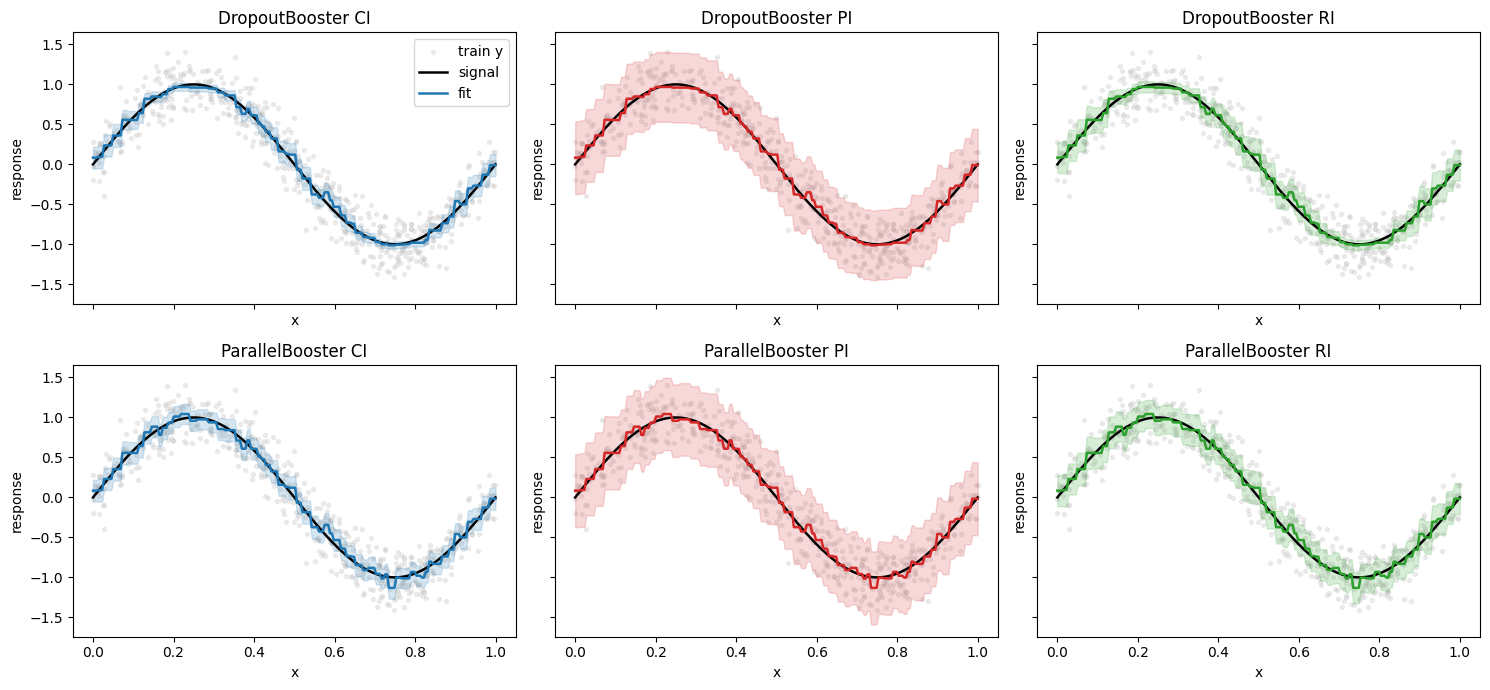

In [8]:
grid = np.linspace(0.0, 1.0, 220)
X_grid_1d = grid.reshape(-1, 1)
truth_grid_1d = signal_1d(X_grid_1d)
mode_colors = {
    "confidence": "#1f77b4",
    "prediction": "#d62728",
    "reproduction": "#2ca02c",
}
mode_labels = {"confidence": "CI", "prediction": "PI", "reproduction": "RI"}

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
for row, name in enumerate(["DropoutBooster", "ParallelBooster"]):
    model = low_dim_models[name]
    for col, mode in enumerate(["confidence", "prediction", "reproduction"]):
        lower, upper, pred = model.predict_intervals(X_grid_1d, level=0.95, mode=mode)
        ax = axes[row, col]
        ax.scatter(
            X1_train[:, 0],
            y1_train,
            s=8,
            color="0.75",
            alpha=0.25,
            label="train y",
        )
        ax.fill_between(grid, lower, upper, color=mode_colors[mode], alpha=0.18)
        ax.plot(grid, truth_grid_1d, color="black", linewidth=1.8, label="signal")
        ax.plot(grid, pred, color=mode_colors[mode], linewidth=1.8, label="fit")
        ax.set_title(f"{name} {mode_labels[mode]}")
        ax.set_xlabel("x")
        ax.set_ylabel("response")
axes[0, 0].legend(loc="best")
fig.tight_layout()


## Higher-Dimensional Additive Example: ExplainableBooster

When dimension grows, start with `ExplainableBooster` if an additive/main-effect model is scientifically acceptable. It gives feature-level intervals and usually avoids the high-dimensional cell explosion that makes global histogram-tree signal intervals fragile.


In [9]:
def signal_additive(X):
    return (
        np.sin(2 * np.pi * X[:, 0])
        + 0.8 * (X[:, 1] - 0.5)
        + 0.4 * np.cos(4 * np.pi * X[:, 2])
    )


def feature_truth(feature_idx, values):
    if feature_idx == 0:
        return np.sin(2 * np.pi * values)
    if feature_idx == 1:
        return 0.8 * (values - 0.5)
    if feature_idx == 2:
        return 0.4 * np.cos(4 * np.pi * values)
    raise ValueError(feature_idx)


X_add = rng.uniform(0.0, 1.0, size=(2500, 3))
signal_add = signal_additive(X_add)
y_add = signal_add + rng.normal(scale=0.25, size=X_add.shape[0])

(
    X_train,
    X_calib,
    X_test,
    y_train,
    y_calib,
    y_test,
    signal_test,
) = split_train_calib_test(X_add, y_add, signal_add)

explainable = bd.ExplainableBooster(
    max_rounds=160,
    max_bins=32,
    learning_rate=0.6,
    subsample_rate=0.6,
    warmup_rounds=20,
    max_depth=8,
    min_samples_leaf=8,
    random_state=0,
)
fit_seconds, prep_seconds = timed_fit_prepare(
    explainable,
    X_train,
    y_train,
    X_calib,
    y_calib,
)
explainable_metrics = evaluate_model(explainable, X_test, y_test, signal_test)

print("ExplainableBooster")
print(f"  fit seconds: {fit_seconds:.3f}")
print(f"  prepare_inference seconds: {prep_seconds:.3f}")
print(f"  predict seconds: {explainable_metrics['pred_seconds']:.4f}")
print(f"  RMSE vs signal: {explainable_metrics['rmse_signal']:.4f}")
print(f"  RMSE vs noisy y: {explainable_metrics['rmse_y']:.4f}")
print(f"  signal CI coverage: {explainable_metrics['ci_coverage']:.3f}")
print(f"  noisy-y PI coverage: {explainable_metrics['pi_coverage']:.3f}")
print(f"  CI width q05/q50/q95: {explainable_metrics['ci_width_quantiles']}")


/Users/longbo/Developer/boulevard-stack/boulevard/src/boulevard/estimators/interpretml/explainable.py:78: UserWarning: ExplainableBooster tree capacity is capped before max_leaves=256: max_bins allows at most about 32 1D leaves; subsample_rate and min_samples_leaf allow at most about 112 leaves per feature update. Increasing max_depth or max_leaves alone is unlikely to change the fit.
  self._warn_about_tree_capacity_caps(n_samples=X.shape[0])


ExplainableBooster
  fit seconds: 0.734
  prepare_inference seconds: 0.015
  predict seconds: 0.0002
  RMSE vs signal: 0.0928
  RMSE vs noisy y: 0.2587
  signal CI coverage: 0.954
  noisy-y PI coverage: 1.000
  CI width q05/q50/q95: [0.3540251  0.3540251  0.35534683]


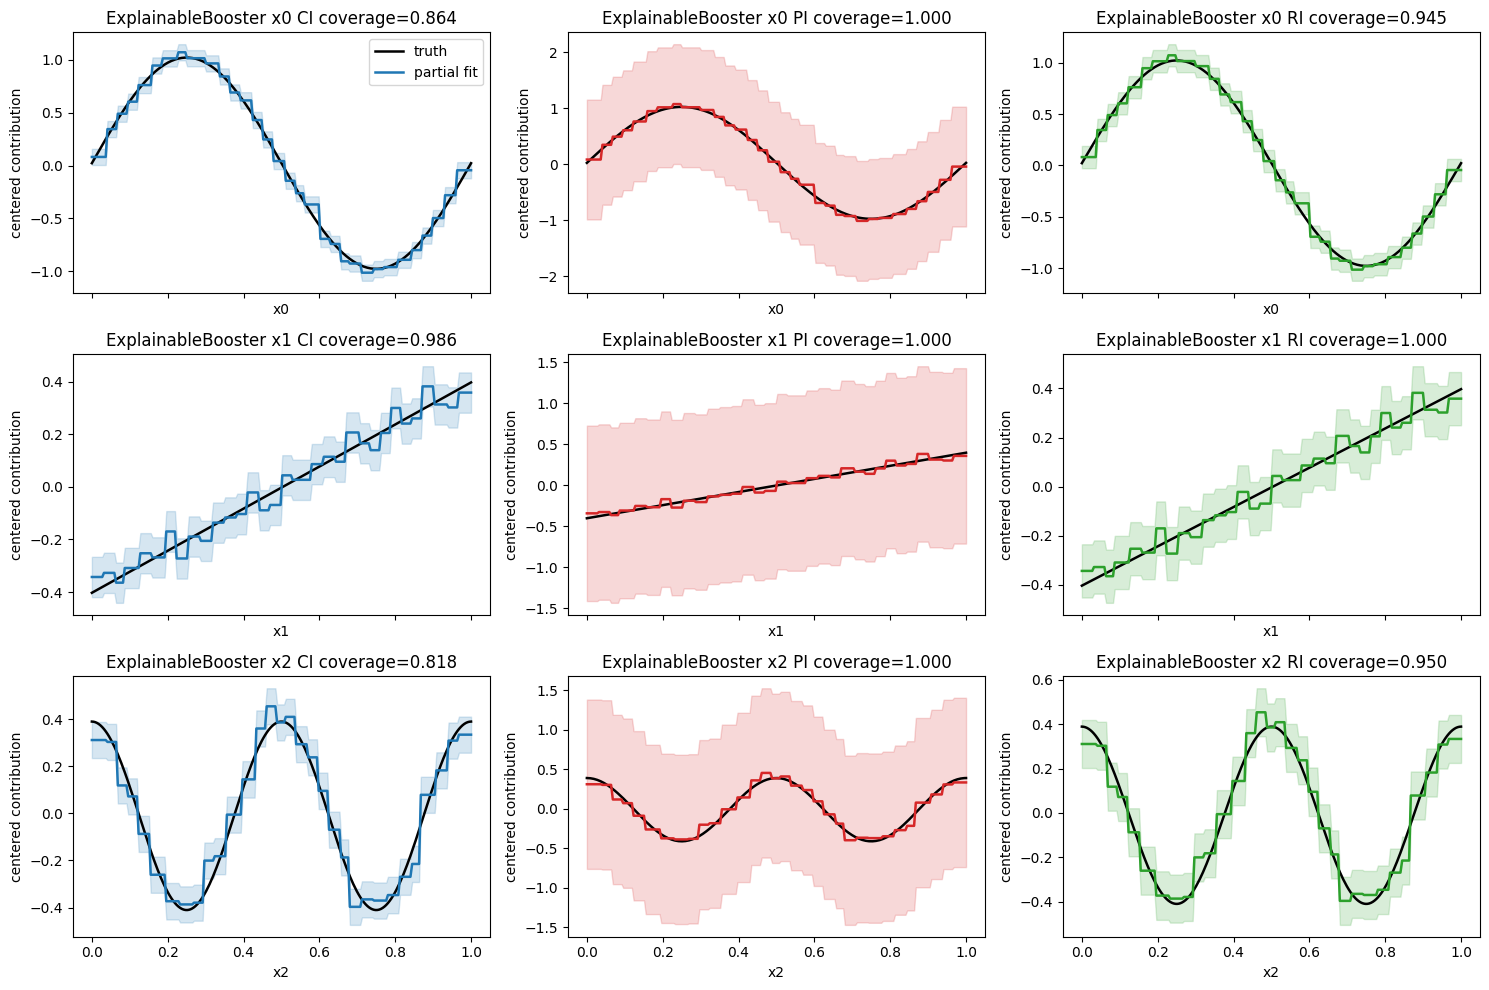

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for feature_idx in range(3):
    centered_truth = feature_truth(feature_idx, grid) - np.mean(
        feature_truth(feature_idx, X_train[:, feature_idx])
    )
    for col, mode in enumerate(["confidence", "prediction", "reproduction"]):
        lower, upper, pred = explainable.predict_feature_intervals(
            feature_idx,
            grid,
            level=0.95,
            mode=mode,
            include_intercept=False,
        )
        feature_coverage = coverage(centered_truth, lower, upper)
        ax = axes[feature_idx, col]
        ax.fill_between(grid, lower, upper, color=mode_colors[mode], alpha=0.18)
        ax.plot(grid, centered_truth, color="black", linewidth=1.8, label="truth")
        ax.plot(grid, pred, color=mode_colors[mode], linewidth=1.8, label="partial fit")
        ax.set_title(
            f"ExplainableBooster x{feature_idx} {mode_labels[mode]} "
            f"coverage={feature_coverage:.3f}"
        )
        ax.set_xlabel(f"x{feature_idx}")
        ax.set_ylabel("centered contribution")
axes[0, 0].legend(loc="best")
fig.tight_layout()


## Appendix

The rule above comes from the standard bias-variance calculation for local-constant partition estimators.

Assume the regression function is $s$-smooth over an effective $r$-dimensional input. A tree with $\ell$ roughly balanced leaves divides the active feature space into cells with side length

$$
h \asymp \ell^{-1/r}.
$$

A local-constant approximation has bias scale

$$
\mathrm{bias} \asymp h^s \asymp \ell^{-s/r},
$$

so squared bias is

$$
\mathrm{bias}^2 \asymp \ell^{-2s/r}.
$$

Each leaf contains about $n/\ell$ observations, so the variance scale of a leaf average is

$$
\mathrm{variance} \asymp \frac{1}{n/\ell} = \frac{\ell}{n}.
$$

The minimax-style choice balances squared bias and variance:

$$
\ell^{-2s/r} \asymp \frac{\ell}{n}.
$$

Rearranging gives

$$
\ell^{1 + 2s/r} \asymp n,
\qquad
\ell^\star \asymp n^{r/(2s+r)}.
$$

The implied leaf size is

$$
m^\star \asymp \frac{n}{\ell^\star}
= n^{2s/(2s+r)}.
$$

For a once-smooth / Lipschitz signal, set $s=1$:

$$
\ell^\star \asymp n^{r/(r+2)},
\qquad
m^\star \asymp n^{2/(r+2)}.
$$

Because `DropoutBooster` grows each tree on a subsample, replace $n$ by $n_{\mathrm{bag}} = \rho n$. A practical version is

$$
\rho = \min(1, 0.75 + 0.05r),
\qquad
\ell_{\mathrm{raw}} = C_{\ell} n_{\mathrm{bag}}^{r/(r+2)},
\qquad
m = C_m n_{\mathrm{bag}}^{2/(r+2)}.
$$

Then cap the actual tree size by finite-sample constraints:

$$
\ell = \min\left(\ell_{\mathrm{cap}}, \left\lfloor \frac{n_{\mathrm{bag}}}{m} \right\rfloor, \left\lceil \ell_{\mathrm{raw}} \right\rceil\right).
$$

The direct tree-parameter translation is

$$
\mathtt{max\_leaf\_nodes} = \ell,
\qquad
\mathtt{max\_depth} = \lceil \log_2(\ell) \rceil + 1,
\qquad
\mathtt{max\_bins} = \min(255, \max(64, \lceil C_b\ell^{1/r} \rceil)).
$$

For `DropoutBooster`, the budget rule is

$$
\mathtt{dropout\_rate} = \min(0.3, 0.3/r),
\qquad
\mathtt{max\_iter} \approx C_T r\ell.
$$

For `ParallelBooster`, use the same $\ell$, $m$, depth, and bin rules, then split the total budget into slots and rounds:

$$
K \approx \min(16, \max(4, 2r)),
\qquad
R \approx \max\left(50, \left\lceil \frac{C_T r\ell}{K} \right\rceil\right),
$$

where $K$ is `trees_per_round` and $R$ is `n_rounds`.

Reasonable diagnostic constants are $C_{\ell} \in [2, 4]$, $C_m \in [0.25, 0.75]$, $C_b \approx 3$, and $C_T \in [2, 6]$. The formulas give the direction of scaling, not a guaranteed default: constants, noise level, interaction order, and sample size still need empirical validation.
